
# Domain-Aware Cost Prediction Experiment

This notebook is a **separate experiment** from the baseline notebook. It keeps the original baseline work untouched and tests whether adding **facilities domain knowledge** improves cost prediction from work order text.

## Consistency with the baseline notebook
This notebook follows the same core regression setup used in the baseline:
- load the three Boise State raw CSV exports
- normalize the raw export headers
- build a `reg_df` dataset
- create `total_cost`
- remove zero-cost rows
- trim the top 1% of cost outliers
- predict `log_cost` with a Ridge regression model

## What this notebook adds
- abbreviation expansion:
  - `vfd` -> `variable_frequency_drive`
  - `ahu` -> `air_handling_unit`
  - `rtu` -> `roof_top_unit`
- domain-aware text augmentation
- structured binary flags
- a fair side-by-side comparison between:
  - **Baseline TF-IDF Ridge**
  - **Domain-aware TF-IDF + flags Ridge**

## Outputs
This notebook also exports:
- `baseline_domain_experiment_worst_100.csv`
- `domain_aware_experiment_worst_100.csv`

Both files contain the worst 100 prediction misses for each model.


In [1]:

# ============================================================
# Imports
# ============================================================

import glob
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)



## Locate the Boise State export files

This notebook looks for all CSV files whose names start with `NLP Report`. That matches the naming style used in the project root.


In [2]:

# ============================================================
# Locate files
# ============================================================

files = sorted(glob.glob("NLP Report*.csv"))

print("Files found:")
for f in files:
    print("-", f)

if len(files) == 0:
    raise FileNotFoundError(
        "No files matching 'NLP Report*.csv' were found in this directory."
    )


Files found:
- NLP Report 2002-2009.csv
- NLP Report 2010-2019.csv
- NLP Report.csv


In [3]:

# ============================================================
# Helper: load one raw export correctly
# ============================================================

def load_workorder_export(path, encoding="latin1"):
    """
    Loads a Boise State maintenance export where:
    row 0 = export timestamp
    row 1 = report title
    row 2 = blank
    row 3 = actual header row
    row 4+ = data
    """
    raw = pd.read_csv(path, header=None, encoding=encoding, low_memory=False)

    header = raw.iloc[3, :11].tolist()
    df = raw.iloc[4:, :11].copy()
    df.columns = header
    df.reset_index(drop=True, inplace=True)

    return df


In [4]:

# ============================================================
# Load and combine all files
# ============================================================

dfs = []
for f in files:
    df_part = load_workorder_export(f)
    df_part["source_file"] = os.path.basename(f)
    dfs.append(df_part)

data = pd.concat(dfs, ignore_index=True)

print("Combined raw shape:", data.shape)
print("\nRaw columns:")
print(data.columns.tolist())
display(data.head())


Combined raw shape: (316979, 12)

Raw columns:
['Request', 'Building Name', 'Request Date', 'Completion Date', 'Priority Code', 'Priority Description', 'Trade Description', 'Total Hours', 'Total Labor Cost', 'Total Material Cost', 'Total Other Cost', 'source_file']


,Request,Building Name,Request Date,Completion Date,Priority Code,Priority Description,Trade Description,Total Hours,Total Labor Cost,Total Material Cost,Total Other Cost,source_file
0,"RM 131, 132, 133, 134 TO COLD - Test DB Migration",Chrisway Annex,10/31/2002,11/04/2002 07:00,1,Routine,HVAC,1.25,$56.25,$0.00,$0.00,NLP Report 2002-2009.csv
1,Closed per Foreman. - Closed per Foreman. - No electricity on one side of the room,Boulder Hall,10/31/2002,12/16/2017 17:00,1,Routine,Electrician,0.5,$13.80,$0.00,$0.00,NLP Report 2002-2009.csv
2,"Reset fire alarm at fire alarm panel, inside of front door. System problem alarm, not fire alarm.\n\nConley radioed/ml",Engineering (RUCH),10/31/2002,12/03/2002 11:12,1,Routine,Electrician,6.25,$172.50,$0.00,"$1,937.30",NLP Report 2002-2009.csv
3,Freezer is not cold.\n\nLA radioed / ml,Copper Basin,10/31/2002,11/15/2002 06:48,1,Routine,HVAC,0.25,$6.63,$0.00,$0.00,NLP Report 2002-2009.csv
4,No air flow.\n\nLarel radioed / ml\nFans down per Larel.\nFans back up - Ed notified by vm / ml,Riverfront Hall,10/31/2002,11/18/2002 07:00,1,Routine,HVAC,0.25,$6.63,$0.00,$0.00,NLP Report 2002-2009.csv



## Normalize columns to match the baseline notebook

The baseline notebook uses cleaned names like:
- `request_text`
- `building_name`
- `request_date`
- `trade_description`
- `total_labor_cost`
- `total_material_cost`
- `total_other_cost`


In [5]:

# ============================================================
# Normalize columns and parse data types
# ============================================================

data.columns = [str(c).strip() for c in data.columns]

rename_map = {
    "Request": "request_text",
    "Building Name": "building_name",
    "Request Date": "request_date",
    "Completion Date": "completion_date",
    "Priority Code": "priority_code",
    "Priority Description": "priority_description",
    "Trade Description": "trade_description",
    "Total Hours": "total_hours",
    "Total Labor Cost": "total_labor_cost",
    "Total Material Cost": "total_material_cost",
    "Total Other Cost": "total_other_cost",
}

data = data.rename(columns=rename_map)

def parse_money(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "":
        return np.nan
    text = text.replace("$", "").replace(",", "")
    try:
        return float(text)
    except ValueError:
        return np.nan

for col in ["total_labor_cost", "total_material_cost", "total_other_cost"]:
    data[col] = data[col].apply(parse_money)

data["total_hours"] = pd.to_numeric(data["total_hours"], errors="coerce")

for col in ["request_date", "completion_date"]:
    data[col] = pd.to_datetime(data[col], errors="coerce")

data["request_text"] = data["request_text"].fillna("").astype(str)
data["building_name"] = data["building_name"].fillna("").astype(str).str.strip()
data["trade_description"] = data["trade_description"].fillna("").astype(str).str.strip()
data["request_year"] = data["request_date"].dt.year

data["total_cost"] = (
    data["total_labor_cost"].fillna(0)
    + data["total_material_cost"].fillna(0)
    + data["total_other_cost"].fillna(0)
)

print("Normalized shape:", data.shape)
print("\nNormalized columns:")
print(data.columns.tolist())

print("\nDtypes:")
print(data.dtypes)

display(data.head())


Normalized shape: (316979, 14)

Normalized columns:
['request_text', 'building_name', 'request_date', 'completion_date', 'priority_code', 'priority_description', 'trade_description', 'total_hours', 'total_labor_cost', 'total_material_cost', 'total_other_cost', 'source_file', 'request_year', 'total_cost']

Dtypes:
request_text                    object
building_name                   object
request_date            datetime64[ns]
completion_date         datetime64[ns]
priority_code                   object
priority_description            object
trade_description               object
total_hours                    float64
total_labor_cost               float64
total_material_cost            float64
total_other_cost               float64
source_file                     object
request_year                   float64
total_cost                     float64
dtype: object


,request_text,building_name,request_date,completion_date,priority_code,priority_description,trade_description,total_hours,total_labor_cost,total_material_cost,total_other_cost,source_file,request_year,total_cost
0,"RM 131, 132, 133, 134 TO COLD - Test DB Migration",Chrisway Annex,2002-10-31,2002-11-04 07:00:00,1,Routine,HVAC,1.25,56.25,0.0,0.0,NLP Report 2002-2009.csv,2002.0,56.25
1,Closed per Foreman. - Closed per Foreman. - No electricity on one side of the room,Boulder Hall,2002-10-31,2017-12-16 17:00:00,1,Routine,Electrician,0.50,13.80,0.0,0.0,NLP Report 2002-2009.csv,2002.0,13.80
2,"Reset fire alarm at fire alarm panel, inside of front door. System problem alarm, not fire alarm.\n\nConley radioed/ml",Engineering (RUCH),2002-10-31,2002-12-03 11:12:00,1,Routine,Electrician,6.25,172.50,0.0,1937.3,NLP Report 2002-2009.csv,2002.0,2109.80
3,Freezer is not cold.\n\nLA radioed / ml,Copper Basin,2002-10-31,2002-11-15 06:48:00,1,Routine,HVAC,0.25,6.63,0.0,0.0,NLP Report 2002-2009.csv,2002.0,6.63
4,No air flow.\n\nLarel radioed / ml\nFans down per Larel.\nFans back up - Ed notified by vm / ml,Riverfront Hall,2002-10-31,2002-11-18 07:00:00,1,Routine,HVAC,0.25,6.63,0.0,0.0,NLP Report 2002-2009.csv,2002.0,6.63



## Build the regression dataset

This follows the same style as the baseline notebook:
- keep rows with real cost info
- recompute `total_cost`
- remove zero-cost rows
- trim top 1% outliers
- create `log_cost`


In [6]:

# ============================================================
# Build clean regression dataset
# ============================================================

reg_df = data.copy()

required_cols = [
    "request_text",
    "total_labor_cost",
    "total_material_cost",
    "total_other_cost",
]

missing = [c for c in required_cols if c not in reg_df.columns]
if missing:
    print("Available columns:")
    print(reg_df.columns.tolist())
    raise ValueError(f"Missing required columns: {missing}")

reg_df = reg_df[
    reg_df["total_labor_cost"].notna()
    | reg_df["total_material_cost"].notna()
    | reg_df["total_other_cost"].notna()
].copy()

reg_df["total_cost"] = (
    reg_df["total_labor_cost"].fillna(0)
    + reg_df["total_material_cost"].fillna(0)
    + reg_df["total_other_cost"].fillna(0)
)

reg_df = reg_df[reg_df["total_cost"] > 0].copy()

upper_limit = reg_df["total_cost"].quantile(0.99)
reg_df = reg_df[reg_df["total_cost"] <= upper_limit].copy()

reg_df["log_cost"] = np.log1p(reg_df["total_cost"])
reg_df["request_text"] = reg_df["request_text"].fillna("").astype(str)

print("Regression dataset shape:", reg_df.shape)
print("Upper outlier cutoff (99th percentile):", round(upper_limit, 2))
print("\nTotal cost summary:")
display(reg_df["total_cost"].describe())


Regression dataset shape: (256363, 15)
Upper outlier cutoff (99th percentile): 4910.44

Total cost summary:


count    256363.000000
mean        206.659271
std         477.854364
min           0.040000
25%          26.480000
50%          60.600000
75%         150.000000
max        4910.000000
Name: total_cost, dtype: float64

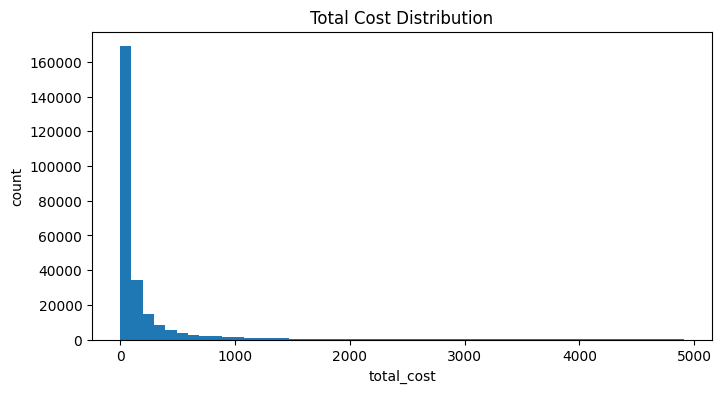

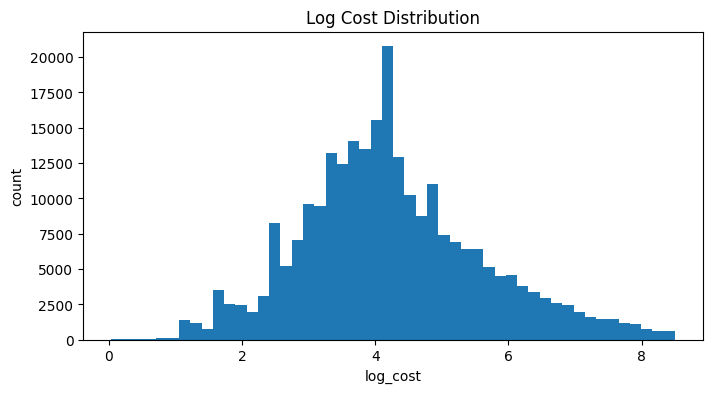

In [7]:

# Quick look at target distributions

plt.figure(figsize=(8, 4))
plt.hist(reg_df["total_cost"], bins=50)
plt.title("Total Cost Distribution")
plt.xlabel("total_cost")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(reg_df["log_cost"], bins=50)
plt.title("Log Cost Distribution")
plt.xlabel("log_cost")
plt.ylabel("count")
plt.show()



## Text preprocessing

The baseline notebook already used:
- `clean_text`
- simple keyword augmentation

This notebook keeps that baseline behavior and then adds:
- abbreviation expansion
- domain-aware tokens
- domain flags


In [8]:

# ============================================================
# Text preprocessing helpers
# ============================================================

ABBREVIATION_MAP = {
    "vfd": "variable_frequency_drive",
    "ahu": "air_handling_unit",
    "rtu": "roof_top_unit",
    "fcu": "fan_coil_unit",
    "ddc": "direct_digital_control",
    "pm": "preventive_maintenance",
    "hvac": "heating_ventilation_air_conditioning",
    "fd": "fire_damper",
    "cuh": "cabinet_unit_heater",
    "btu": "british_thermal_unit",
    "wc": "water_closet",
    "ef": "exhaust_fan",
    "mcc": "motor_control_center",
    "vav": "variable_air_volume",
}

def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ")
    text = text.replace("/", " ")
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9_\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def add_baseline_keywords(text):
    text = str(text).lower()

    if any(word in text for word in ["paint", "painted", "repaint"]):
        text += " painting_keyword"

    if any(word in text for word in ["door", "frame", "wood", "cabinet"]):
        text += " carpentry_keyword"

    return text

def expand_abbreviations(text, abbreviation_map=ABBREVIATION_MAP):
    words = str(text).split()
    expanded_words = [abbreviation_map.get(word, word) for word in words]
    return " ".join(expanded_words)

def add_domain_tokens(text):
    text = str(text).lower()
    added = []

    if re.search(r"\bvfd\b|\bvariable_frequency_drive\b|\bvariable frequency drive\b", text):
        added.extend(["expensive_hvac_component", "motor_drive_system"])

    if re.search(r"\breplace\b|\breplacement\b", text):
        added.append("replacement_work")

    if re.search(r"\binstall\b|\binstallation\b", text):
        added.append("installation_work")

    if re.search(r"\bquote\b|\bestimate\b|\bproposal\b", text):
        added.append("quote_related")

    if re.search(r"\bdanfoss\b|\bab\b|\ballen bradley\b|\bsiemens\b|\btrane\b|\byork\b", text):
        added.append("equipment_brand")

    if re.search(r"\bcard reader\b|\baccess control\b|\block\b|\brekey\b|\bkey\b", text):
        added.append("security_access_system")

    if re.search(r"\bhvac\b|\bheating_ventilation_air_conditioning\b|\bair_handling_unit\b|\broof_top_unit\b|\bboiler\b|\bchiller\b|\bvariable_air_volume\b", text):
        added.append("hvac_mechanical_scope")

    if re.search(r"\bpanel\b|\bbreaker\b|\bdisconnect\b|\btransformer\b|\bvoltage\b|\b480v\b|\b277v\b", text):
        added.append("electrical_scope")

    if re.search(r"\bplumb\w*\b|\bleak\b|\bvalve\b|\bpipe\b|\bwater_closet\b|\bwc\b", text):
        added.append("plumbing_scope")

    if re.search(r"\bmaintenance\b|\bchecks\b|\broutine\b|\bvarious\b", text):
        added.append("vague_scope_language")

    if added:
        text = text + " " + " ".join(added)

    return text

def preprocess_baseline(series):
    return (
        series.fillna("")
        .astype(str)
        .apply(clean_text)
        .apply(add_baseline_keywords)
    )

def preprocess_domain(series):
    return (
        series.fillna("")
        .astype(str)
        .apply(clean_text)
        .apply(expand_abbreviations)
        .apply(add_baseline_keywords)
        .apply(add_domain_tokens)
    )


In [9]:

# ============================================================
# Structured domain flags
# ============================================================

def build_domain_flags(series):
    text = series.fillna("").astype(str).str.lower()

    flags = pd.DataFrame(index=series.index)
    flags["has_vfd"] = text.str.contains(r"\bvfd\b|\bvariable frequency drive\b", regex=True).astype(int)
    flags["has_replace"] = text.str.contains(r"\breplace\b|\breplacement\b", regex=True).astype(int)
    flags["has_install"] = text.str.contains(r"\binstall\b|\binstallation\b", regex=True).astype(int)
    flags["has_hvac"] = text.str.contains(r"\bhvac\b|\bahu\b|\brtu\b|\bfcu\b|\bboiler\b|\bchiller\b|\bvav\b", regex=True).astype(int)
    flags["has_electrical"] = text.str.contains(r"\belectrical\b|\bpanel\b|\bbreaker\b|\bdisconnect\b|\btransformer\b|\b480v\b|\b277v\b", regex=True).astype(int)
    flags["has_plumbing"] = text.str.contains(r"\bplumb\w*\b|\bleak\b|\bvalve\b|\bpipe\b|\bwc\b|\bwater closet\b", regex=True).astype(int)
    flags["has_security"] = text.str.contains(r"\block\b|\bcard reader\b|\baccess control\b|\brekey\b|\bkey\b", regex=True).astype(int)
    flags["has_brand"] = text.str.contains(r"\bdanfoss\b|\btrane\b|\bsiemens\b|\ballen bradley\b|\bab\b|\byork\b", regex=True).astype(int)
    flags["has_quote"] = text.str.contains(r"\bquote\b|\bestimate\b|\bproposal\b", regex=True).astype(int)
    flags["has_number"] = text.str.contains(r"\d", regex=True).astype(int)
    flags["has_voltage"] = text.str.contains(r"\b\d+\s?v\b|\b480v\b|\b277v\b|\b208v\b|\b120v\b", regex=True).astype(int)
    flags["has_hp"] = text.str.contains(r"\b\d+\s?hp\b", regex=True).astype(int)
    flags["is_vague"] = text.str.contains(r"\bmaintenance\b|\bchecks\b|\broutine\b|\bvarious\b|\bminor maintenance\b", regex=True).astype(int)
    flags["word_count"] = text.str.split().str.len().fillna(0).astype(int)

    return flags

sample_flags = build_domain_flags(reg_df["request_text"].head(5))
display(sample_flags)


,has_vfd,has_replace,has_install,has_hvac,has_electrical,has_plumbing,has_security,has_brand,has_quote,has_number,has_voltage,has_hp,is_vague,word_count
0,0,0,0,0,0,0,0,0,0,1,0,0,0,11
1,0,0,0,0,0,0,0,0,0,0,0,0,0,16
2,0,0,0,0,1,0,0,0,0,0,0,0,0,19
3,0,0,0,0,0,0,0,0,0,0,0,0,0,8
4,0,0,0,0,0,0,0,0,0,0,0,0,0,21



## Shared train/test split

Both models use the **same split**, so the comparison is fair.

- **Baseline model**: TF-IDF on cleaned text
- **Domain-aware model**: TF-IDF on expanded/augmented text + binary flags


In [11]:

# ============================================================
# Shared train/test split
# ============================================================

BASELINE_TFIDF_KWARGS = dict(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=15,
    max_df=0.8,
    stop_words="english",
)

X_raw = reg_df["request_text"]
y = reg_df["log_cost"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
)

X_train_baseline_text = preprocess_baseline(X_train_raw)
X_test_baseline_text = preprocess_baseline(X_test_raw)

X_train_domain_text = preprocess_domain(X_train_raw)
X_test_domain_text = preprocess_domain(X_test_raw)

X_train_flags = build_domain_flags(X_train_raw)
X_test_flags = build_domain_flags(X_test_raw)

print("Train size:", len(X_train_raw))
print("Test size:", len(X_test_raw))
print("\nSample baseline text:")
print(X_train_baseline_text.iloc[0][:300])

print("\nSample domain-aware text:")
print(X_train_domain_text.iloc[0][:300])


Train size: 205090
Test size: 51273

Sample baseline text:
to rearrange the furniture please note that the desks are extremely heavy and take multiple people to move also i would like to be here when the move occurs and i work a short schedule in the summer it would be great if someone could contact me regarding the timing so that they don t show up unexpec

Sample domain-aware text:
to rearrange the furniture please note that the desks are extremely heavy and take multiple people to move also i would like to be here when the move occurs and i work a short schedule in the summer it would be great if someone could contact me regarding the timing so that they don t show up unexpec


In [12]:

# ============================================================
# Baseline model
# ============================================================

baseline_vectorizer = TfidfVectorizer(**BASELINE_TFIDF_KWARGS)

X_train_baseline_vec = baseline_vectorizer.fit_transform(X_train_baseline_text)
X_test_baseline_vec = baseline_vectorizer.transform(X_test_baseline_text)

baseline_model = Ridge(alpha=1.0, solver="lsqr")
baseline_model.fit(X_train_baseline_vec, y_train)

baseline_pred_log = baseline_model.predict(X_test_baseline_vec)
baseline_pred_actual = np.expm1(baseline_pred_log)
y_test_actual = np.expm1(y_test)

baseline_results = pd.DataFrame({
    "text": X_test_raw.reset_index(drop=True),
    "actual_cost": y_test_actual.reset_index(drop=True),
    "predicted_cost": baseline_pred_actual,
})

baseline_results["abs_error"] = (
    baseline_results["actual_cost"] - baseline_results["predicted_cost"]
).abs()

baseline_results["error_ratio"] = (
    baseline_results["abs_error"] / baseline_results["actual_cost"].replace(0, np.nan)
)

baseline_metrics = {
    "model": "Baseline TF-IDF Ridge",
    "mae_log": mean_absolute_error(y_test, baseline_pred_log),
    "rmse_log": np.sqrt(mean_squared_error(y_test, baseline_pred_log)),
    "mae_actual": mean_absolute_error(y_test_actual, baseline_pred_actual),
    "rmse_actual": np.sqrt(mean_squared_error(y_test_actual, baseline_pred_actual)),
    "r2_log": r2_score(y_test, baseline_pred_log),
}

baseline_metrics


{'model': 'Baseline TF-IDF Ridge',
 'mae_log': 0.7618783636399127,
 'rmse_log': np.float64(1.0193330814105395),
 'mae_actual': 149.89039077606475,
 'rmse_actual': np.float64(432.9970974353996),
 'r2_log': 0.4397704316196881}

In [13]:

# ============================================================
# Domain-aware model
# ============================================================

domain_vectorizer = TfidfVectorizer(**BASELINE_TFIDF_KWARGS)

X_train_domain_vec = domain_vectorizer.fit_transform(X_train_domain_text)
X_test_domain_vec = domain_vectorizer.transform(X_test_domain_text)

X_train_flags_sparse = csr_matrix(X_train_flags.values)
X_test_flags_sparse = csr_matrix(X_test_flags.values)

X_train_domain_final = hstack([X_train_domain_vec, X_train_flags_sparse])
X_test_domain_final = hstack([X_test_domain_vec, X_test_flags_sparse])

domain_model = Ridge(alpha=1.0, solver="lsqr")
domain_model.fit(X_train_domain_final, y_train)

domain_pred_log = domain_model.predict(X_test_domain_final)
domain_pred_actual = np.expm1(domain_pred_log)

domain_results = pd.DataFrame({
    "text": X_test_raw.reset_index(drop=True),
    "actual_cost": y_test_actual.reset_index(drop=True),
    "predicted_cost": domain_pred_actual,
})

domain_results["abs_error"] = (
    domain_results["actual_cost"] - domain_results["predicted_cost"]
).abs()

domain_results["error_ratio"] = (
    domain_results["abs_error"] / domain_results["actual_cost"].replace(0, np.nan)
)

domain_metrics = {
    "model": "Domain-aware TF-IDF + flags Ridge",
    "mae_log": mean_absolute_error(y_test, domain_pred_log),
    "rmse_log": np.sqrt(mean_squared_error(y_test, domain_pred_log)),
    "mae_actual": mean_absolute_error(y_test_actual, domain_pred_actual),
    "rmse_actual": np.sqrt(mean_squared_error(y_test_actual, domain_pred_actual)),
    "r2_log": r2_score(y_test, domain_pred_log),
}

domain_metrics


{'model': 'Domain-aware TF-IDF + flags Ridge',
 'mae_log': 0.7784663239146327,
 'rmse_log': np.float64(1.0366697694571012),
 'mae_actual': 151.28428421221034,
 'rmse_actual': np.float64(437.0028197324518),
 'r2_log': 0.4205517480699449}

In [14]:

# ============================================================
# Side-by-side comparison
# ============================================================

comparison_df = pd.DataFrame([baseline_metrics, domain_metrics])
display(comparison_df)

if comparison_df.loc[1, "rmse_actual"] < comparison_df.loc[0, "rmse_actual"]:
    print("Domain-aware model has lower RMSE in actual dollars.")
else:
    print("Baseline model has lower RMSE in actual dollars.")

if comparison_df.loc[1, "mae_actual"] < comparison_df.loc[0, "mae_actual"]:
    print("Domain-aware model has lower MAE in actual dollars.")
else:
    print("Baseline model has lower MAE in actual dollars.")


,model,mae_log,rmse_log,mae_actual,rmse_actual,r2_log
0,Baseline TF-IDF Ridge,0.761878,1.019333,149.890391,432.997097,0.439770
1,Domain-aware TF-IDF + flags Ridge,0.778466,1.036670,151.284284,437.002820,0.420552


Baseline model has lower RMSE in actual dollars.
Baseline model has lower MAE in actual dollars.



## Inspect worst predictions


In [15]:

# Top 10 worst rows for each model

baseline_worst_10 = baseline_results.sort_values("abs_error", ascending=False).head(10).copy()
domain_worst_10 = domain_results.sort_values("abs_error", ascending=False).head(10).copy()

print("===== BASELINE MODEL: TOP 10 WORST =====")
display(baseline_worst_10)

print("===== DOMAIN-AWARE MODEL: TOP 10 WORST =====")
display(domain_worst_10)


===== BASELINE MODEL: TOP 10 WORST =====


,text,actual_cost,predicted_cost,abs_error,error_ratio
46737,HVAC: Boilers Service,4855.55,84.105505,4771.444495,0.982678
32407,"In LA the carpet in the main area of the writing center (200, 201, 220 a b, 202, 206) is loose and wrinkled up throughout. \n\nAccount #: 881A100001",4864.12,94.027911,4770.092089,0.980669
37927,-911A100007; -Metal Detector batteries (90);\n1001.91108.5402007\n\n\nAccount code 519900,4817.11,55.117624,4761.992376,0.988558
19651,"MAINT: Repair exterior clock on the NE corner of the AFC building;\nMisc. Activities/Actions, Statues/Monuments/Clock Towers/Flag Poles",4856.00,96.958569,4759.041431,0.980033
3256,Daily Building Checks,4785.94,62.132816,4723.807184,0.987018
36938,Install vent damper on top of elevator shaft.\nObtain proposal(s) to install a gravity damper on the roof atop the northwest elevator shaft. Suggest a unit to match the damper on the north centra...,4873.69,157.098987,4716.591013,0.967766
24498,Pool mechanical routine maintenance,4878.37,178.825853,4699.544147,0.963343
31821,Install owner provided wall paper in the new Trueblood and Gipson Meeting rooms. Install chair rail to be made by the campus wood shop. Chg. to #987L103008,4903.59,204.302599,4699.287401,0.958336
30904,"includes seminars/ conferences / in-house training , irrigation horticulture and arborist, includes training on vehicles and equipment, WeTMA, and other office",4819.50,125.178170,4694.321830,0.974027
2116,HVAC: Loop chemical check and adjust chemical levels; record levels to work order,4759.94,65.669814,4694.270186,0.986204


===== DOMAIN-AWARE MODEL: TOP 10 WORST =====


,text,actual_cost,predicted_cost,abs_error,error_ratio
46737,HVAC: Boilers Service,4855.55,54.636656,4800.913344,0.988748
32407,"In LA the carpet in the main area of the writing center (200, 201, 220 a b, 202, 206) is loose and wrinkled up throughout. \n\nAccount #: 881A100001",4864.12,69.371770,4794.748230,0.985738
19651,"MAINT: Repair exterior clock on the NE corner of the AFC building;\nMisc. Activities/Actions, Statues/Monuments/Clock Towers/Flag Poles",4856.00,83.447994,4772.552006,0.982815
31821,Install owner provided wall paper in the new Trueblood and Gipson Meeting rooms. Install chair rail to be made by the campus wood shop. Chg. to #987L103008,4903.59,143.173809,4760.416191,0.970802
37927,-911A100007; -Metal Detector batteries (90);\n1001.91108.5402007\n\n\nAccount code 519900,4817.11,63.608993,4753.501007,0.986795
19558,Compressor on unit will not work.,4826.59,93.778142,4732.811858,0.980571
24498,Pool mechanical routine maintenance,4878.37,149.222112,4729.147888,0.969411
3256,Daily Building Checks,4785.94,70.464357,4715.475643,0.985277
2116,HVAC: Loop chemical check and adjust chemical levels; record levels to work order,4759.94,54.818913,4705.121087,0.988483
14134,Batch Closed. - Irrigation - Renovation and all Maintenance for Housing,4882.41,178.804652,4703.605348,0.963378


In [16]:

# Export worst 100 for each model

baseline_worst_100 = baseline_results.sort_values("abs_error", ascending=False).head(100).copy()
domain_worst_100 = domain_results.sort_values("abs_error", ascending=False).head(100).copy()

baseline_worst_100.to_csv("baseline_domain_experiment_worst_100.csv", index=False)
domain_worst_100.to_csv("domain_aware_experiment_worst_100.csv", index=False)

print("Exported:")
print("- baseline_domain_experiment_worst_100.csv")
print("- domain_aware_experiment_worst_100.csv")


Exported:
- baseline_domain_experiment_worst_100.csv
- domain_aware_experiment_worst_100.csv



## Check VFD-like rows

This focuses on the exact kind of nuance that motivated the experiment.


In [17]:

def filter_rows_containing(df, pattern):
    return df[df["text"].astype(str).str.contains(pattern, case=False, regex=True)].copy()

baseline_vfd_rows = filter_rows_containing(
    baseline_results,
    r"\bvfd\b|variable frequency drive"
)

domain_vfd_rows = filter_rows_containing(
    domain_results,
    r"\bvfd\b|variable frequency drive"
)

print("Baseline VFD-like rows in test results:", len(baseline_vfd_rows))
display(baseline_vfd_rows.head(20))

print("Domain-aware VFD-like rows in test results:", len(domain_vfd_rows))
display(domain_vfd_rows.head(20))


Baseline VFD-like rows in test results: 68


,text,actual_cost,predicted_cost,abs_error,error_ratio
130,\nVFD is OFFLINE as reported by Metasys.\nTroubleshoot and correct.\n,401.30,66.317504,334.982496,0.834743
665,Closed per Foreman. - Rocky Yoneda 12/19/2017 17:34 -No charge for the display \nBrett Bogardus 12/19/2017 13:04 -installed display from used VFD. complete. \nVFD control display is blank. ETC 1-w...,45.00,322.558311,277.558311,6.167962
1263,"HVAC: At the SMASH Building there is no power to vfd;\n""Gerald Graham 05/17/2021 10:20 - \nno power to vfd""\nHVAC: Equipment Activities / Adjustments / Repairs / Upgrades / Replacements",216.32,284.758164,68.438164,0.316375
3514,HVAC: Need to order and replace the small cooling fans in the VFD;\nHVAC: Equipment Activities / Adjustments / Repairs / Upgrades / Replacements,189.76,474.452871,284.692871,1.500279
3694,"HVAC: Install resistive break on VFD 2 in Education;\n\n""Gerald Graham 06/14/2021 13:10 - Install resistive break on VFD 2""\nHVAC: Equipment Activities / Adjustments / Repairs / Upgrades / Replace...",162.50,441.802438,279.302438,1.718784
6357,HVAC: Service Return Fan VFD,32.50,74.569308,42.069308,1.294440
6418,vfd to pump 6 not working \n,392.39,83.178916,309.211084,0.788020
6592,"\nSERVICE BULLETIN C0406\n\nJeff Figuroa, Carrier Intermountain, changed out the balancing and discharge resistors in the Liquiflo VFD in accordance with Carrier Service Bulletin C0406.\n",3.44,62.690684,59.250684,17.224036
7291,HVAC: VFD Service,32.50,84.105505,51.605505,1.587862
7931,"HVAC: Exhaust fan VFD in alarm, need to troubleshoot;\nHVAC: Equipment/Environmental Alarms",87.50,88.671742,1.171742,0.013391


Domain-aware VFD-like rows in test results: 68


,text,actual_cost,predicted_cost,abs_error,error_ratio
130,\nVFD is OFFLINE as reported by Metasys.\nTroubleshoot and correct.\n,401.30,83.328474,317.971526,0.792354
665,Closed per Foreman. - Rocky Yoneda 12/19/2017 17:34 -No charge for the display \nBrett Bogardus 12/19/2017 13:04 -installed display from used VFD. complete. \nVFD control display is blank. ETC 1-w...,45.00,294.942284,249.942284,5.554273
1263,"HVAC: At the SMASH Building there is no power to vfd;\n""Gerald Graham 05/17/2021 10:20 - \nno power to vfd""\nHVAC: Equipment Activities / Adjustments / Repairs / Upgrades / Replacements",216.32,213.772752,2.547248,0.011775
3514,HVAC: Need to order and replace the small cooling fans in the VFD;\nHVAC: Equipment Activities / Adjustments / Repairs / Upgrades / Replacements,189.76,374.550308,184.790308,0.973811
3694,"HVAC: Install resistive break on VFD 2 in Education;\n\n""Gerald Graham 06/14/2021 13:10 - Install resistive break on VFD 2""\nHVAC: Equipment Activities / Adjustments / Repairs / Upgrades / Replace...",162.50,380.341278,217.841278,1.340562
6357,HVAC: Service Return Fan VFD,32.50,55.715427,23.215427,0.714321
6418,vfd to pump 6 not working \n,392.39,62.804849,329.585151,0.839943
6592,"\nSERVICE BULLETIN C0406\n\nJeff Figuroa, Carrier Intermountain, changed out the balancing and discharge resistors in the Liquiflo VFD in accordance with Carrier Service Bulletin C0406.\n",3.44,56.260368,52.820368,15.354758
7291,HVAC: VFD Service,32.50,50.385774,17.885774,0.550332
7931,"HVAC: Exhaust fan VFD in alarm, need to troubleshoot;\nHVAC: Equipment/Environmental Alarms",87.50,67.096117,20.403883,0.233187



## Inspect influential text features

For Ridge, coefficient interpretation is easiest on the text portion of the model.

For the domain-aware model, the first chunk of coefficients corresponds to the TF-IDF text features, followed by the appended binary flags.


In [18]:

def top_text_coefficients(model, vectorizer, top_n=25):
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = np.asarray(model.coef_[:len(feature_names)])

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
    })

    positive = coef_df.sort_values("coef", ascending=False).head(top_n)
    negative = coef_df.sort_values("coef", ascending=True).head(top_n)

    return positive, negative

baseline_pos, baseline_neg = top_text_coefficients(
    baseline_model,
    baseline_vectorizer,
    top_n=25
)

domain_pos, domain_neg = top_text_coefficients(
    domain_model,
    domain_vectorizer,
    top_n=25
)

print("===== BASELINE: TOP POSITIVE TEXT FEATURES =====")
display(baseline_pos)

print("===== DOMAIN-AWARE: TOP POSITIVE TEXT FEATURES =====")
display(domain_pos)

print("===== DOMAIN-AWARE: TOP NEGATIVE TEXT FEATURES =====")
display(domain_neg)


===== BASELINE: TOP POSITIVE TEXT FEATURES =====


,feature,coef
2933,water test,4.277554
357,alarm inspections,3.321548
1145,estimate fm,3.223268
2867,upgrades,3.210312
584,build,3.109268
1473,hydronic water,2.986795
2298,recycling,2.870010
2903,visual,2.853065
2830,turf,2.652115
784,commencement,2.551744


===== DOMAIN-AWARE: TOP POSITIVE TEXT FEATURES =====


,feature,coef
575,build,2.123033
2246,purchase,2.092733
733,clean building,2.010253
1073,elect,1.982093
842,contract,1.960517
2828,turf,1.954039
2300,recycling,1.913321
584,buildings,1.747837
2172,pool,1.675500
2772,tma,1.670116


===== DOMAIN-AWARE: TOP NEGATIVE TEXT FEATURES =====


,feature,coef
1177,extinguisher inspections,-2.211918
1495,inspect elevators,-1.819220
2295,record,-1.768909
607,campus record,-1.725648
2730,thank,-1.652855
2266,radioed,-1.491891
2735,thanks,-1.450043
943,day access,-1.401645
2533,sign,-1.292418
2719,test eyewash,-1.233741



## Notes

If the domain-aware model does **not** improve dramatically right away, that is still useful.

Likely reasons:
- many work order descriptions are too vague to encode real scope
- cost may depend on hidden structured fields not present in the text
- some domain terms are rare
- some expensive work orders still look linguistically simple

### Strong next steps
- add requester/source features
- add building or shop/trade features
- extract quantities, voltages, and horsepower more directly
- train separate models by trade family
- compare performance on only high-cost jobs


## Experiment 1: Add scope/scale features that TF-IDF misses
What this tests
Your text model already catches words like “replace,” “vfd,” and “ahu,” but expensive jobs are often expensive because of scope, not just vocabulary.
Examples:
multiple units
long bundled descriptions
quantities
numbers + equipment terms
“replace 3 pumps and controls”
“full rebuild”
“material + labor + access issues”
staff-written detailed descriptions
This experiment adds explicit numeric and binary features that try to capture scope and operational complexity.
Why it may help high-cost prediction
High-cost jobs are often the ones where:
the description is longer
there are more numbers
more equipment references appear
more action verbs appear
multiple tasks are bundled together
the text sounds more technical
That can help the model stop treating:
“replace vfd”
and
“replace 3 vfd drives and controls wiring in mechanical room”
as nearly the same job.
What success looks like
Success is:
lower actual-dollar RMSE
less underprediction in top-cost deciles
better error on the most expensive jobs, even if MAE stays similar

In [19]:
# Experiment 1: TF-IDF + engineered scope/scale features

import re
import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix, hstack

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# -----------------------------
# Safety checks
# -----------------------------
required_cols = ["request_text", "log_cost", "total_cost"]
missing = [c for c in required_cols if c not in reg_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = reg_df.copy()
df["request_text"] = df["request_text"].fillna("").astype(str)

# Keep only rows with valid targets
df = df[df["log_cost"].notna() & df["total_cost"].notna()].copy()


# -----------------------------
# Train/test split
# -----------------------------
X = df["request_text"]
y_log = df["log_cost"]
y_actual = df["total_cost"]

X_train, X_test, y_train_log, y_test_log, y_train_actual, y_test_actual = train_test_split(
    X, y_log, y_actual, test_size=0.2, random_state=42
)


# -----------------------------
# Helper: engineered text features
# -----------------------------
class WorkOrderScopeFeatures(BaseEstimator, TransformerMixin):
    """
    Extracts simple numeric/binary features from maintenance request text.
    These features are intended to capture scope, scale, technicality,
    bundling, and signals that correlate with high-cost jobs.
    """
    def __init__(self):
        self.equipment_terms = [
            "vfd", "ahu", "rtu", "chiller", "boiler", "pump", "motor", "compressor",
            "valve", "coil", "belt", "fan", "bearing", "actuator", "transformer",
            "panel", "breaker", "relay", "thermostat", "sensor", "damper",
            "generator", "condenser", "evaporator", "filter"
        ]
        self.action_terms = [
            "replace", "repair", "install", "remove", "rebuild", "retrofit",
            "upgrade", "inspect", "diagnose", "troubleshoot", "clean", "adjust",
            "test", "service", "patch", "rewire"
        ]
        self.scope_terms = [
            "multiple", "several", "entire", "full", "complete", "all",
            "throughout", "campus", "building", "room", "rooms", "floor",
            "floors", "suite", "area", "system", "systems"
        ]
        self.material_terms = [
            "material", "parts", "part", "supply", "supplies", "wire", "wiring",
            "pipe", "piping", "conduit", "duct", "controls", "control"
        ]
        self.urgency_terms = [
            "urgent", "emergency", "asap", "immediately", "critical", "failure",
            "failed", "down", "not working", "no heat", "no cooling", "leak"
        ]

    def fit(self, X, y=None):
        return self

    def _count_matches(self, text, vocab):
        tokens = re.findall(r"\b[a-zA-Z0-9\-]+\b", text.lower())
        return sum(1 for t in tokens if t in vocab)

    def _extract_one(self, text):
        text = str(text)
        text_lower = text.lower()

        # Basic counts
        char_len = len(text)
        word_tokens = re.findall(r"\b[a-zA-Z0-9\-]+\b", text)
        word_count = len(word_tokens)

        numbers = re.findall(r"\b\d+(?:\.\d+)?\b", text_lower)
        number_count = len(numbers)
        max_number = max([float(n) for n in numbers], default=0.0)

        # Acronyms / technical style
        uppercase_tokens = re.findall(r"\b[A-Z]{2,}\b", text)
        uppercase_count = len(uppercase_tokens)

        # Counts by domain vocab
        equipment_count = self._count_matches(text, self.equipment_terms)
        action_count = self._count_matches(text, self.action_terms)
        scope_count = self._count_matches(text, self.scope_terms)
        material_count = self._count_matches(text, self.material_terms)
        urgency_count = self._count_matches(text, self.urgency_terms)

        # Signs of bundled/multi-part work
        and_count = len(re.findall(r"\band\b", text_lower))
        comma_count = text.count(",")
        semicolon_count = text.count(";")
        slash_count = text.count("/")

        # Flags
        has_replace = int("replace" in text_lower)
        has_install = int("install" in text_lower)
        has_repair = int("repair" in text_lower)
        has_vfd = int("vfd" in text_lower)
        has_ahu = int("ahu" in text_lower)
        has_rtu = int("rtu" in text_lower)
        has_room_ref = int(bool(re.search(r"\broom\b|\brm\b|\bunit\b|\bunits\b", text_lower)))
        has_quantity_gt1 = int(any(float(n) > 1 for n in numbers))
        has_technical_acronym = int(uppercase_count > 0)
        long_description = int(word_count >= 12)

        # Rough complexity score
        complexity_score = (
            equipment_count
            + action_count
            + scope_count
            + material_count
            + urgency_count
            + and_count
            + comma_count
            + semicolon_count
            + slash_count
            + number_count
        )

        return [
            char_len,
            word_count,
            number_count,
            max_number,
            uppercase_count,
            equipment_count,
            action_count,
            scope_count,
            material_count,
            urgency_count,
            and_count,
            comma_count,
            semicolon_count,
            slash_count,
            has_replace,
            has_install,
            has_repair,
            has_vfd,
            has_ahu,
            has_rtu,
            has_room_ref,
            has_quantity_gt1,
            has_technical_acronym,
            long_description,
            complexity_score
        ]

    def transform(self, X):
        features = np.array([self._extract_one(text) for text in X], dtype=float)
        return csr_matrix(features)


feature_names_scope = [
    "char_len",
    "word_count",
    "number_count",
    "max_number",
    "uppercase_count",
    "equipment_count",
    "action_count",
    "scope_count",
    "material_count",
    "urgency_count",
    "and_count",
    "comma_count",
    "semicolon_count",
    "slash_count",
    "has_replace",
    "has_install",
    "has_repair",
    "has_vfd",
    "has_ahu",
    "has_rtu",
    "has_room_ref",
    "has_quantity_gt1",
    "has_technical_acronym",
    "long_description",
    "complexity_score"
]


# -----------------------------
# Baseline TF-IDF
# -----------------------------
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    strip_accents="unicode",
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

baseline_model = Ridge(alpha=3.0)
baseline_model.fit(X_train_tfidf, y_train_log)

baseline_pred_log = baseline_model.predict(X_test_tfidf)
baseline_pred_actual = np.expm1(baseline_pred_log).clip(min=0)

baseline_results = {
    "model": "baseline_tfidf_ridge",
    "mae_log": mean_absolute_error(y_test_log, baseline_pred_log),
    "rmse_log": np.sqrt(mean_squared_error(y_test_log, baseline_pred_log)),
    "mae_actual": mean_absolute_error(y_test_actual, baseline_pred_actual),
    "rmse_actual": np.sqrt(mean_squared_error(y_test_actual, baseline_pred_actual))
}


# -----------------------------
# TF-IDF + scope features
# -----------------------------
scope_fe = WorkOrderScopeFeatures()

X_train_scope = scope_fe.fit_transform(X_train)
X_test_scope = scope_fe.transform(X_test)

X_train_combined = hstack([X_train_tfidf, X_train_scope]).tocsr()
X_test_combined = hstack([X_test_tfidf, X_test_scope]).tocsr()

scope_model = Ridge(alpha=3.0)
scope_model.fit(X_train_combined, y_train_log)

scope_pred_log = scope_model.predict(X_test_combined)
scope_pred_actual = np.expm1(scope_pred_log).clip(min=0)

scope_results = {
    "model": "tfidf_plus_scope_features",
    "mae_log": mean_absolute_error(y_test_log, scope_pred_log),
    "rmse_log": np.sqrt(mean_squared_error(y_test_log, scope_pred_log)),
    "mae_actual": mean_absolute_error(y_test_actual, scope_pred_actual),
    "rmse_actual": np.sqrt(mean_squared_error(y_test_actual, scope_pred_actual))
}

results_df = pd.DataFrame([baseline_results, scope_results])
display(results_df)


# -----------------------------
# High-cost focused diagnostics
# -----------------------------
comparison = pd.DataFrame({
    "request_text": X_test.reset_index(drop=True),
    "actual_cost": y_test_actual.reset_index(drop=True),
    "baseline_pred": baseline_pred_actual,
    "scope_pred": scope_pred_actual
})

comparison["baseline_abs_error"] = (comparison["actual_cost"] - comparison["baseline_pred"]).abs()
comparison["scope_abs_error"] = (comparison["actual_cost"] - comparison["scope_pred"]).abs()

top90_cutoff = comparison["actual_cost"].quantile(0.90)
high_cost = comparison[comparison["actual_cost"] >= top90_cutoff].copy()

high_cost_summary = pd.DataFrame([
    {
        "subset": "top_10pct_actual_cost",
        "baseline_mae": high_cost["baseline_abs_error"].mean(),
        "scope_mae": high_cost["scope_abs_error"].mean(),
        "baseline_underprediction_mean": (high_cost["actual_cost"] - high_cost["baseline_pred"]).mean(),
        "scope_underprediction_mean": (high_cost["actual_cost"] - high_cost["scope_pred"]).mean()
    }
])

display(high_cost_summary)

print("Top 20 expensive jobs: baseline vs scope-feature model")
display(
    comparison.sort_values("actual_cost", ascending=False)[
        ["request_text", "actual_cost", "baseline_pred", "scope_pred", "baseline_abs_error", "scope_abs_error"]
    ].head(20)
)


KeyboardInterrupt



## Experiment 2: Cost-weighted Ridge to punish underprediction on expensive jobs
What this tests
Your baseline is probably optimizing for the huge mass of cheaper jobs. That usually gives decent MAE but weak RMSE, because the model learns that being wrong on a giant repair is “rare enough” to ignore.
This experiment keeps the same basic model, but tells Ridge:
“Errors on expensive jobs matter more.”
Why it may help high-cost prediction
If the model underpredicts big jobs, one of the cleanest fixes is to weight training examples by cost.
This does not require a new model family. It directly addresses your loss mismatch:
the training objective currently treats all rows similarly
your real pain is not symmetric across the cost range
What success looks like
Success is:
lower actual-dollar RMSE
reduced mean underprediction on top-cost jobs
maybe slightly worse MAE on cheap routine work, which is acceptable if big misses shrink

In [ ]:
# Experiment 2: Cost-weighted Ridge regression

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# -----------------------------
# Safety checks
# -----------------------------
required_cols = ["request_text", "log_cost", "total_cost"]
missing = [c for c in required_cols if c not in reg_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = reg_df.copy()
df["request_text"] = df["request_text"].fillna("").astype(str)
df = df[df["log_cost"].notna() & df["total_cost"].notna()].copy()


# -----------------------------
# Train/test split
# -----------------------------
X = df["request_text"]
y_log = df["log_cost"]
y_actual = df["total_cost"]

X_train, X_test, y_train_log, y_test_log, y_train_actual, y_test_actual = train_test_split(
    X, y_log, y_actual, test_size=0.2, random_state=42
)


# -----------------------------
# TF-IDF
# -----------------------------
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    strip_accents="unicode",
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


# -----------------------------
# Helper: evaluate model
# -----------------------------
def evaluate_predictions(name, y_true_log, y_pred_log, y_true_actual):
    y_pred_actual = np.expm1(y_pred_log).clip(min=0)
    return {
        "model": name,
        "mae_log": mean_absolute_error(y_true_log, y_pred_log),
        "rmse_log": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "mae_actual": mean_absolute_error(y_true_actual, y_pred_actual),
        "rmse_actual": np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    }, y_pred_actual


# -----------------------------
# Baseline model
# -----------------------------
baseline = Ridge(alpha=3.0)
baseline.fit(X_train_tfidf, y_train_log)
baseline_pred_log = baseline.predict(X_test_tfidf)

baseline_metrics, baseline_pred_actual = evaluate_predictions(
    "baseline_ridge", y_test_log, baseline_pred_log, y_test_actual
)


# -----------------------------
# Weighted models
# -----------------------------
# Weight function idea:
#   cheap jobs get weight near 1
#   expensive jobs get larger weights
#
# We'll try several strengths and keep the one with best actual RMSE.
#
# Using percentile rank is safer than raw dollars because cost scale can be ugly.

train_cost_rank = pd.Series(y_train_actual).rank(pct=True).to_numpy()

candidate_settings = [
    {"name": "weighted_x2", "alpha": 3.0, "max_boost": 2.0},
    {"name": "weighted_x3", "alpha": 3.0, "max_boost": 3.0},
    {"name": "weighted_x5", "alpha": 3.0, "max_boost": 5.0},
    {"name": "weighted_x3_alpha10", "alpha": 10.0, "max_boost": 3.0},
]

weighted_results = []
weighted_predictions = {}

for cfg in candidate_settings:
    # Smoothly increase weight with cost percentile
    sample_weight = 1.0 + train_cost_rank * (cfg["max_boost"] - 1.0)

    model = Ridge(alpha=cfg["alpha"])
    model.fit(X_train_tfidf, y_train_log, sample_weight=sample_weight)

    pred_log = model.predict(X_test_tfidf)
    metrics, pred_actual = evaluate_predictions(
        cfg["name"], y_test_log, pred_log, y_test_actual
    )

    weighted_results.append(metrics)
    weighted_predictions[cfg["name"]] = pred_actual

results_df = pd.DataFrame([baseline_metrics] + weighted_results).sort_values("rmse_actual")
display(results_df)


# -----------------------------
# Choose best weighted model
# -----------------------------
best_weighted_name = results_df.iloc[0]["model"]

if best_weighted_name == "baseline_ridge":
    best_weighted_pred_actual = baseline_pred_actual
else:
    best_weighted_pred_actual = weighted_predictions[best_weighted_name]

comparison = pd.DataFrame({
    "request_text": X_test.reset_index(drop=True),
    "actual_cost": y_test_actual.reset_index(drop=True),
    "baseline_pred": baseline_pred_actual,
    "best_weighted_pred": best_weighted_pred_actual
})

comparison["baseline_error"] = comparison["actual_cost"] - comparison["baseline_pred"]
comparison["weighted_error"] = comparison["actual_cost"] - comparison["best_weighted_pred"]

comparison["baseline_abs_error"] = comparison["baseline_error"].abs()
comparison["weighted_abs_error"] = comparison["weighted_error"].abs()

top90_cutoff = comparison["actual_cost"].quantile(0.90)
high_cost = comparison[comparison["actual_cost"] >= top90_cutoff].copy()

summary = pd.DataFrame([
    {
        "subset": "top_10pct_actual_cost",
        "baseline_mae": high_cost["baseline_abs_error"].mean(),
        "weighted_mae": high_cost["weighted_abs_error"].mean(),
        "baseline_mean_underprediction": high_cost["baseline_error"].mean(),
        "weighted_mean_underprediction": high_cost["weighted_error"].mean()
    }
])

display(summary)

print(f"Best weighted model selected: {best_weighted_name}")

display(
    comparison.sort_values("actual_cost", ascending=False)[
        ["request_text", "actual_cost", "baseline_pred", "best_weighted_pred",
         "baseline_abs_error", "weighted_abs_error"]
    ].head(20)
)